# Kinematics |  Angular Head Velocity
-----------------------------------------

## Setup and Configuration

In [1]:
##### Imports ##########################################################################

#==== Generic Imports ================
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from IPython.display import display, Markdown
from collections.abc import Callable

#==== Movement Imports ===============
import movement.kinematics
import movement.utils.vector

#==== DataConduit Imports (Core) =====
import data_conduit as dc
from data_conduit.datastructures import slice_stream, slice_stream_per_trial
from data_conduit.integrations.DLC.pose import pose_to_movement  # Import used for combining DLC pose & confidence streams into a single object
#       matches `movement`'s own conventions

#==== DataConduit Imports (Unique) ===
from movement_figures.data_template.loading import build_datastructure

from movement_figures.misc import visual_streams_check, configure_simplified_trial_df
from movement_figures.timeseries_template.annotations import annotate_qc_timeseries

from data_conduit.refactor_qc import (  # Imports for trial filtering based on experiment protocol
    TRAINING_FIRST_MID_LAST_DETAIL,
    training_spec,
    training_session_names,
    filter_trials,
)
from movement_figures.timeseries_template.annotations import AnnotationResult

### Notebook Settings ######################################################

pd.set_option("display.max_columns", None)  # Changes default pandas display settings to show all columns in a dataframe.
pd.set_option("display.max_rows", None)  # Changes default pandas display settings to show all rows in a dataframe.

In [2]:
##### Setup Parameters #################################################################

# === 1| Select Mice, Days and Recording Folders Before Reading Files =============
ROOT = Path("/media/sepi/Elements/PathIntegrationProtocol/BonsaiOutput/Training")

LEVEL_SELECTORS = {
    'l0_selector': 'MR_M01569515', 
    'l1_selector': 'Day21'
    }                                                                                       # Example choices belong here: l0_selector and l1_selector.
# INCLUDE_SESSIONS = ('2026-06-21T093349Z',)                                                # Optional list of recording folder names; None keeps selected folders.
# STREAMS = ('trials', 'events', 'video', 'dlc')                                            # These figures require events/trials and aligned pose; other sources remain available.


#=== 2| Set the trial filtering parameters for the experiment protocol ============
spec = training_spec(TRAINING_FIRST_MID_LAST_DETAIL)                                        # Flattens `{training_detail}` table into per-session spec. 

# included_sessions = training_session_names(spec)                                          # Returns a list of session folder names that match the spec.
#   Not used here, as sessions have been filtered in another way. If other sessions 
#   not in the above spec are used, then applying the `filter_trials` function with 
#   the above spec could result in incorrect filtering.


In [3]:
##### Load DataStructure ###############################################################

#=== Load data ========================================================================

fig_ds_obj = build_datastructure(
    root               = ROOT,                                                                 # Directory above the named hierarchy levels.
    level_names        = ("mouseID", "day"),                                                   # Lab layout: root / mouseID / day / session.
    streams            = ("trials", "session_settings", "video", "dlc"),                       # Data streams to be included in the datastructure.
    include            = None,                                                                 # Keep these session folder names; None keeps all.
    exclude            = None,                                                                 # Alternatively omit these session folder names.
    raw_events         = True,                                                                 # Convenience alias for adding "events" to the requested sources.
    device_yaml        = "./device.yml",                                                       # Lab Nosepoke board register definitions.
    soundcard_yaml     = "./soundcard.yml",                                                    # Lab SoundCard register definitions.
    nosepoke_count     = 18,                                                                   # Port count used by the existing Q_C parser.
    trial_start_buffer = 0.0,                                                                  # Preserve the existing lab parser setting.
    dlc_file_format     = "auto",                                                              # Existing reader prefers CSV, otherwise HDF5.
    trial_spec = None,                                                                         # Optional experiment rules; None keeps the existing Q_C specification. 
    #    Not used here, as sessions are already selected. 
    #    If session is not one in the spec, then subsequent use of 
    #   `filter_trials` to apply correct experiment protocol rules could be incorrect.
    
    **LEVEL_SELECTORS,
)


#=== Select and load the streams of interest from datastructure. ======================
fig_ds_obj.select()
streams = fig_ds_obj.load()                                                                    # Load is required to access the selected streams.

#=== Create convenient compact trial dataframe without some unnecessary columns. ======
streams['compact_trials'] = configure_simplified_trial_df(              
    trial_df = streams['trials'],
    modify_in_place = False,                                                                   # Whether to modify the trial dataframe in place or return a new dataframe. 
)
'''More useful for visual inspection and analysis. 
Check the misc.py file for the default columns to keep and drop.'''


#=== Apply Trial Filtering Protocol to construct new stream objects ===================

# Full filtered trials
streams['filtered_trials'] = filter_trials(
    trials = streams['trials'],
    spec = spec,
    # session_column = 'session', mouse_column = 'mouseID', trial_index_column = 'trial_index', led_column = 'LED', report = True,
    #                                                            # Leave params untouched for now, let the function use its defaults.
)

# Filtered compact trials 
streams['filtered_compact_trials'] = filter_trials(
    trials = streams['compact_trials'],
    spec = spec,
    # session_column = 'session', mouse_column = 'mouseID', trial_index_column = 'trial_index', led_column = 'LED', report = True,
    #                                                            # Leave params untouched for now, let the function use its defaults.
)

#=== Merge Pose & Confidence Streams ==================================================
streams['dlc:movement'] = pose_to_movement(
    slice_stream(streams["dlc:position"],   
                #selectors={"session": session_id}
    ),
    slice_stream(streams["dlc:confidence"], 
                 #selectors={"session": session_id}
    ),
)

#=== Visual streams check =============================================================
visual_streams_check(
    loaded_ds_object = streams,                                                                # Loaded dataset object containing all streams of interest.
    show_stream_shapes = True,                                                                 # Whether to display the shapes of the streams.
    show_stream_dtypes = True,                                                                 # Whether to display the data types of the streams.
    display_streams = False                                                                    # Whether to display the actual stream data as a table.
)



     mouseID  training_day            session  n_total  min_trial  n_after_cut  exclude_on  n_on_dropped  n_kept
MR_M01569515             3 2026-06-21T093349Z      106         24           83        True             3      80
     mouseID  training_day            session  n_total  min_trial  n_after_cut  exclude_on  n_on_dropped  n_kept
MR_M01569515             3 2026-06-21T093349Z      106         24           83        True             3      80


=========================
### Summary of Loaded Streams
=========================

,Stream Name,Shape,Type
0,session_settings:metadata,"(1, 23)",DataFrame
1,session_settings:trials,"(303, 132)",DataFrame
2,video,"(36354, 5)",DataFrame
3,dlc:position,"(36354, 5, 2)",DataArray
4,dlc:confidence,"(36354, 5)",DataArray
5,events,"(1487, 5)",DataFrame
6,trials,"(106, 28)",DataFrame
7,compact_trials,"(106, 19)",DataFrame
8,filtered_trials,"(80, 30)",DataFrame
9,filtered_compact_trials,"(80, 21)",DataFrame


## Select Trials to Show

In [4]:
##### Trial Selection ##################################################################

#==== Extract Trial Range ============
selected_trials = slice_stream(streams['filtered_trials'][:8])              # Select the first n trials

#==== Extract Recording Identifier ===
sessionID = selected_trials['session'].unique().item()                      # Extract unique sID from selected trials, remove duplicates, ensure single value.

#==== Select Tracked Positions =======
recording = slice_stream(stream = streams['dlc:movement'],                  # selectors{} here keeps movement data belonging to the specified session only.
                        selectors = {'session' : sessionID }, 
)

position = recording['position']                                            # ['position'] extracts positional data from the movement stream.

position = position.sel(individual='individual_0',                          # .sel() selects the specified individual from the positional data.
                        drop=True,                                          # drop=True removes the individual dimension from the resulting DataArray, but leaves other dims intact.
)


## Compute Angular Head Velocity

Method based on Keshavarzi et al (2022):

 1. Smooth HD over 50ms.
 2. Calculate AHV over 200ms window by taking first derivative of smoothed HD timeseries.

In [5]:

from numpy.polynomial import Polynomial


##### Smoothing Utils ##################################################################


def convert_to_smooth_timeseries(
        data: xr.DataArray,
        smoothing_window_duration: float | None = None,
        fixed_element_window: int | None = None,
        drop_before_min_range: bool = True,
        preserve_dropped_shape: bool = True,
        dropped_value: float = np.nan,
        smoothing_statistic: str = 'mean'
) -> xr.DataArray:
    '''
    Smooth a time-indexed DataArray using a trailing mean or median window.
    Supply either a window duration or a fixed number of observations.

    Parameters
    ----------
    data : xr.DataArray
        Values with one dimension named 'time', indexed by increasing numeric
        seconds. Angular values must already be unwrapped.
    smoothing_window_duration : float | None, optional
        Window duration in seconds, ending at the current time. Default is None.
    fixed_element_window : int | None, optional
        Number of observations per window, including the current observation.
        Default is None.
    drop_before_min_range : bool, optional
        Skip initial windows until the full duration or count is available.
        Default is True.
    preserve_dropped_shape : bool, optional
        Keep skipped initial times with dropped_value if True; remove them if
        False. Default is True.
    dropped_value : float, optional
        Value used for skipped initial observations. Default is np.nan.
    smoothing_statistic : str, optional
        Statistic calculated within each window: 'mean' or 'median'.
        Default is 'mean'.

    Returns
    -------
    xr.DataArray
        Smoothed values with the original coordinates and attributes.
        Windows containing missing or infinite values return NaN.
        Time boundaries use direct comparisons with the stored timestamps.
    '''

    #==== 0| Validation Checks =========================================================

    # Check that the values have one dimension with an explicit time coordinate.
    if data.dims != ('time',):
        raise ValueError("data must have one dimension named 'time'.")

    if 'time' not in data.coords:
        raise ValueError("data must have a numeric 'time' coordinate in seconds.")

    # Check that timestamps are finite and increase throughout the recording.
    times = data.time.values



    #==== 1| Create Missing Results at the Original Times ================================

    smoothed = xr.full_like(data, np.nan, dtype=float)                              # Copy the input shape and coordinates; fill the values with NaN.
    first_output_index = 0                                                          # Initially keep every time point.


    #==== 2| Select Each Window and Calculate the Mean or Median =========================

    for index, current_time in enumerate(times):

        # Select observations from the window's starting time to the current time.
        if smoothing_window_duration is not None:
            start_time = current_time - smoothing_window_duration
            window = data.sel(time=slice(start_time, current_time))
            full_window = start_time >= times[0]                                    # Did the recording begin early enough to cover this window?

        # Alternatively, select the requested number of observations.
        else:
            start_index = max(0, index + 1 - fixed_element_window)                  # Do not start before the first observation.
            window = data.isel(time=slice(start_index, index + 1))                  # The stop position is excluded, so add one to include the current observation.
            full_window = index + 1 >= fixed_element_window

        # Skip initial windows that are shorter than requested.
        if drop_before_min_range and not full_window:
            smoothed.values[index] = dropped_value
            first_output_index = index + 1                                          # The next observation becomes the first one to retain.
            continue

        # Keep NaN if any observation in this window is missing or infinite.
        if not np.isfinite(window.values).all():
            continue

        # Calculate the chosen statistic and store it at the current time.
        if smoothing_statistic == 'mean':
            smoothed.values[index] = np.mean(window.values)
        else:
            smoothed.values[index] = np.median(window.values)


    #==== 3| Remove Skipped Initial Times if Requested ==================================

    if not preserve_dropped_shape:
        smoothed = smoothed.isel(time=slice(first_output_index, None))              # Keep all observations from the first retained one onwards.

    return smoothed


##### Derivative Utils #################################################################


def compute_timeseries_derivative(
        data: xr.DataArray,
        derivative_window_duration: float | None = None,
        fixed_element_window: int | None = None,
        drop_before_min_range: bool = True,
        preserve_dropped_shape: bool = True,
        derivative_order: int = 1,
        polynomial_degree: int = 1
) -> xr.DataArray:
    '''
    Fit a polynomial within each trailing window and calculate its nth derivative
    at the current time.

    Parameters
    ----------
    data : xr.DataArray
        Values with one dimension named 'time', indexed by increasing numeric
        seconds. Angular values must already be unwrapped.
    derivative_window_duration : float | None, optional
        Window duration in seconds, ending at the current time. Default is None.
    fixed_element_window : int | None, optional
        Number of observations per window, including the current observation.
        Supply either this count or a duration. Default is None.
    drop_before_min_range : bool, optional
        Skip initial windows until the full duration or count is available.
        Default is True.
    preserve_dropped_shape : bool, optional
        Keep skipped initial times as NaN if True; remove them if False.
        Default is True.
    derivative_order : int, optional
        Derivative to calculate: 1 for the first, 2 for the second, and so on.
        Must be between 1 and polynomial_degree. Default is 1.
    polynomial_degree : int, optional
        Degree of the fitted polynomial: 1 for a line, 2 for a quadratic,
        3 for a cubic, and so on. Default is 1.

    Returns
    -------
    xr.DataArray
        Derivative evaluated at each window's final timestamp.
        Windows with missing values or fewer than polynomial_degree + 1
        observations return NaN.
        Coordinates are retained and an existing units attribute is updated.
        Time boundaries use direct comparisons with the stored timestamps.
        Smoothing is performed separately.
    '''

    #==== 0| Validation Checks =========================================================

    # Check that the values have one dimension with an explicit time coordinate.
    if data.dims != ('time',):
        raise ValueError("data must have one dimension named 'time'.")

    if 'time' not in data.coords:
        raise ValueError("data must have a numeric 'time' coordinate in seconds.")

    # Check that timestamps are finite and increase throughout the recording.
    times = data.time.values
    if not np.isfinite(times).all() or np.any(times[1:] <= times[:-1]):
        raise ValueError("Time values must be finite and strictly increasing.")

    # Require one window: either a duration or a number of observations.
    if derivative_window_duration is None and fixed_element_window is None:
        raise ValueError("Supply a window duration or an observation count.")

    if derivative_window_duration is not None and fixed_element_window is not None:
        raise ValueError("Supply only one window.")

    # Check the window length, polynomial degree and derivative order.
    if derivative_window_duration is not None:
        if not np.isfinite(derivative_window_duration) or derivative_window_duration <= 0:
            raise ValueError("Window duration must be finite and positive.")

    if not 1 <= derivative_order <= polynomial_degree:
        raise ValueError("Require 1 <= derivative_order <= polynomial_degree.")

    if fixed_element_window is not None and fixed_element_window < polynomial_degree + 1:
        raise ValueError("The window needs at least polynomial_degree + 1 observations.")


    #==== 1| Create Missing Results at the Original Times ================================

    derivative = xr.full_like(data, np.nan, dtype=float)                            # Copy the input shape and coordinates; fill the values with NaN.
    first_output_index = 0                                                          # Initially keep every time point.


    #==== 2| Select Each Window and Calculate the Fitted Derivative ======================

    for index, current_time in enumerate(times):

        # Select observations from the window's starting time to the current time.
        if derivative_window_duration is not None:
            start_time = current_time - derivative_window_duration
            window = data.sel(time=slice(start_time, current_time))
            full_window = start_time >= times[0]                                    # Did the recording begin early enough to cover this window?

        # Alternatively, select the requested number of observations.
        else:
            start_index = max(0, index + 1 - fixed_element_window)                  # Do not start before the first observation.
            window = data.isel(time=slice(start_index, index + 1))                  # The stop position is excluded, so add one to include the current observation.
            full_window = index + 1 >= fixed_element_window

        # Skip initial windows that are shorter than requested.
        if drop_before_min_range and not full_window:
            first_output_index = index + 1                                          # The next observation becomes the first one to retain.
            continue

        # A degree-d polynomial needs at least d + 1 points, all with valid values.
        if window.size < polynomial_degree + 1 or not np.isfinite(window.values).all():
            continue

        # Fit the chosen polynomial to the values against their actual times.
        fitted_curve = Polynomial.fit(
            x=window.time.values,                                                   # Original timestamps in seconds.
            y=window.values,                                                        # Observed values in this window.
            deg=polynomial_degree,                                                  # Degree supplied by the caller.
        )

        # Differentiate the fitted curve and evaluate it at the current time.
        derivative_curve = fitted_curve.deriv(m=derivative_order)                   # Differentiate the polynomial the requested number of times.
        derivative.values[index] = derivative_curve(current_time)                   # Store the derivative at this window's final timestamp.


    #==== 3| Return the Derivative Values ===============================================

    # Remove only the initial observations skipped before a full window was available.
    if not preserve_dropped_shape:
        derivative = derivative.isel(time=slice(first_output_index, None))

    # Include the time denominator in the derivative's units, if units were supplied.
    if 'units' in data.attrs:
        derivative.attrs['units'] = f"({data.attrs['units']})/s^{derivative_order}"

    return derivative


In [6]:
# ##### Derivative Utils (endpoint and mean-step) ########################################

# def compute_timeseries_first_derivative(
#         data: xr.DataArray,
#         derivative_window_duration: float | None = None,
#         fixed_element_window: int | None = None,
#         drop_before_min_range: bool = True,
#         preserve_dropped_shape: bool = True,
#         method: str = 'endpoint',
# ) -> xr.DataArray:
#     '''
#     Calculate the first derivative at each time point from a trailing window,
#     without fitting a polynomial.

#     Parameters
#     ----------
#     data : xr.DataArray
#         Values with one dimension named 'time', indexed by increasing numeric
#         seconds. Angular values must already be unwrapped.
#     derivative_window_duration : float | None, optional
#         Window duration in seconds, ending at the current time. Default is None.
#     fixed_element_window : int | None, optional
#         Number of observations per window, including the current observation.
#         Supply either this count or a duration. Default is None.
#     drop_before_min_range : bool, optional
#         Skip initial windows until the full duration or count is available.
#         Default is True.
#     preserve_dropped_shape : bool, optional
#         Keep skipped initial times as NaN if True; remove them if False.
#         Default is True.
#     method : str, optional
#         'endpoint': (y2 - y1) / (x2 - x1), using the first and last samples in
#         the window. Needs at least 2 samples.
#         'mean_step': mean of the per-step slopes, mean(diff(y) / diff(x)),
#         i.e. a rolling average of the change per interval. Needs at least
#         3 samples; windows with exactly 2 samples fall back to 'endpoint'.
#         Default is 'endpoint'.

#     Returns
#     -------
#     xr.DataArray
#         Derivative evaluated at each window's final timestamp.
#         Windows with fewer than 2 observations or any non-finite value
#         return NaN. An existing units attribute is updated.
#     '''

#     #==== 0| Validation Checks =========================================================

#     if data.dims != ('time',):
#         raise ValueError("data must have one dimension named 'time'.")

#     if 'time' not in data.coords:
#         raise ValueError("data must have a numeric 'time' coordinate in seconds.")

#     times = data.time.values
#     if not np.isfinite(times).all() or np.any(times[1:] <= times[:-1]):
#         raise ValueError("Time values must be finite and strictly increasing.")

#     if derivative_window_duration is None and fixed_element_window is None:
#         raise ValueError("Supply a window duration or an observation count.")

#     if derivative_window_duration is not None and fixed_element_window is not None:
#         raise ValueError("Supply only one window.")

#     if derivative_window_duration is not None:
#         if not np.isfinite(derivative_window_duration) or derivative_window_duration <= 0:
#             raise ValueError("Window duration must be finite and positive.")

#     if fixed_element_window is not None and fixed_element_window < 2:
#         raise ValueError("The window needs at least 2 observations.")

#     if method not in ('endpoint', 'mean_step'):
#         raise ValueError("method must be 'endpoint' or 'mean_step'.")


#     #==== 1| Create Missing Results at the Original Times ================================

#     derivative = xr.full_like(data, np.nan, dtype=float)
#     first_output_index = 0


#     #==== 2| Select Each Window and Calculate the Derivative =============================

#     for index, current_time in enumerate(times):

#         # Select observations from the window's starting time to the current time.
#         if derivative_window_duration is not None:
#             start_time = current_time - derivative_window_duration
#             window = data.sel(time=slice(start_time, current_time))
#             full_window = start_time >= times[0]

#         # Alternatively, select the requested number of observations.
#         else:
#             start_index = max(0, index + 1 - fixed_element_window)
#             window = data.isel(time=slice(start_index, index + 1))
#             full_window = index + 1 >= fixed_element_window

#         # Skip initial windows that are shorter than requested.
#         if drop_before_min_range and not full_window:
#             first_output_index = index + 1
#             continue

#         # Need two valid points to form a slope.
#         if window.size < 2 or not np.isfinite(window.values).all():
#             continue

#         y = window.values
#         x = window.time.values

#         if method == 'mean_step' and window.size > 2:
#             derivative.values[index] = np.mean(np.diff(y) / np.diff(x))             # Rolling average of per-interval velocity.
#         else:
#             derivative.values[index] = (y[-1] - y[0]) / (x[-1] - x[0])              # (y2 - y1) / (x2 - x1)


#     #==== 3| Return the Derivative Values ===============================================

#     if not preserve_dropped_shape:
#         derivative = derivative.isel(time=slice(first_output_index, None))

#     if 'units' in data.attrs:
#         derivative.attrs['units'] = f"({data.attrs['units']})/s"

#     return derivative


In [7]:
from numbers import Integral, Real

import numpy as np
import xarray as xr


##### Derivative Utils #################################################################


def compute_timeseries_first_derivative(
        data: xr.DataArray,
        derivative_window_duration: float | None = None,
        fixed_element_window: int | None = None,
        drop_before_min_range: bool = True,
        preserve_dropped_shape: bool = True,
        method: str = 'endpoint'
) -> xr.DataArray:
    '''
    Calculate the first derivative using endpoint changes or changes between
    consecutive trailing-window means.
    Supply either a window duration or a fixed number of observations.

    Parameters
    ----------
    data : xr.DataArray
        Real numeric values with one dimension named 'time', indexed by finite,
        strictly increasing numeric seconds. Angular values must already be
        unwrapped.
    derivative_window_duration : float | None, optional
        Positive window duration in seconds, ending at the current time.
        Both time boundaries are included. Default is None.
    fixed_element_window : int | None, optional
        Number of observations per window, including the current observation.
        Must be an integer of at least 2. Supply either this count or a duration.
        Default is None.
    drop_before_min_range : bool, optional
        Skip initial windows until the full duration or count is available.
        Exclude these skipped windows from mean comparisons. Default is True.
    preserve_dropped_shape : bool, optional
        Keep skipped initial times as NaN if True; remove them if False.
        Has no effect when drop_before_min_range is False. Default is True.
    method : str, optional
        'endpoint': divide the change between the first and last window values
        by their elapsed time.
        'mean_difference': divide the change between consecutive window means
        by the time between those frames. Both windows must contain at least
        3 observations, all finite, and satisfy drop_before_min_range.
        If either mean is unavailable or non-finite, use the endpoint slope.
        Default is 'endpoint'.

    Returns
    -------
    xr.DataArray
        Derivative stored at each window's final timestamp.
        Windows with missing or infinite values, or fewer than 2 observations,
        return NaN.
        The input name, coordinates and attributes are retained, except for any
        removed initial times. An existing units attribute becomes '(<units>)/s'.

    Raises
    ------
    ValueError
        If the data, timestamps, window arguments or method are invalid.
    '''

    #==== 0| Validation Checks =========================================================

    # Check that the values have one dimension with an explicit numeric time coordinate.
    if not isinstance(data, xr.DataArray) or data.dims != ('time',):
        raise ValueError("data must be an xr.DataArray with one dimension named 'time'.")

    if 'time' not in data.coords or data.time.dtype.kind not in 'iuf':
        raise ValueError("The 'time' coordinate must contain numeric seconds.")

    # Check that observations are real numbers; missing values are checked per window.
    if data.dtype.kind not in 'iuf':
        raise ValueError("data must contain real numeric values.")

    # Check that timestamps are finite and increase throughout the recording.
    times = data.time.values.astype(float)
    if not np.isfinite(times).all() or np.any(times[1:] <= times[:-1]):
        raise ValueError("Time values must be finite and strictly increasing.")

    # Require one window: either a duration or a number of observations.
    if derivative_window_duration is None and fixed_element_window is None:
        raise ValueError("Supply a window duration or an observation count.")

    if derivative_window_duration is not None and fixed_element_window is not None:
        raise ValueError("Supply only one window.")

    # Check that the duration is a finite positive number, excluding True and False.
    if derivative_window_duration is not None:
        if (
            isinstance(derivative_window_duration, bool)
            or not isinstance(derivative_window_duration, Real)
            or not np.isfinite(derivative_window_duration)
            or derivative_window_duration <= 0
        ):
            raise ValueError("Window duration must be a finite positive number.")

    # Check that the observation count is an integer of at least two.
    if fixed_element_window is not None:
        if (
            isinstance(fixed_element_window, bool)
            or not isinstance(fixed_element_window, Integral)
            or fixed_element_window < 2
        ):
            raise ValueError("The window must contain an integer number of at least 2 observations.")

        fixed_element_window = int(fixed_element_window)                            # Use a Python integer when calculating slice positions.

    # Check that the requested method matches one of the two derivative calculations.
    if method not in ('endpoint', 'mean_difference'):
        raise ValueError("method must be 'endpoint' or 'mean_difference'.")


    #==== 1| Create Missing Results at the Original Times ================================

    values = data.values.astype(float)                                              # Convert observations to floating point for the derivative calculations.
    frame_count = len(times)                                                        # Keep one output position for each original observation.
    derivative_values = np.full(frame_count, np.nan)                                # Leave NaN wherever a derivative cannot be calculated.
    window_means = np.full(frame_count, np.nan)                                     # Leave NaN wherever a window cannot be used in a mean comparison.
    first_output_index = 0                                                          # Initially keep every time point.
    first_mean_frame = None                                                         # First frame whose window mean is valid; it has no earlier mean to compare with.

    #==== 2| Select Each Window and Calculate the First Derivative ======================

    for frame in range(frame_count):

        # Select observations from the window's starting time to the current time.
        if derivative_window_duration is not None:
            window_start_time = times[frame] - derivative_window_duration
            first_frame = np.searchsorted(times, window_start_time, side='left')    # Include the first observation at or after the starting time.
            window_is_full = window_start_time >= times[0]                          # Did the recording begin early enough to cover this window?

        # Alternatively, select the requested number of observations.
        else:
            first_frame = max(0, frame + 1 - fixed_element_window)                  # Do not start before the first observation.
            window_is_full = frame + 1 >= fixed_element_window

        # Skip initial short windows, leaving their derivatives and means as NaN.
        if drop_before_min_range and not window_is_full:
            first_output_index = frame + 1                                          # The next observation becomes the first one to retain.
            continue

        window_values = values[first_frame:frame + 1]                               # The stop position is excluded, so add one to include the current observation.

        # Keep NaN if fewer than two observations exist or any value is missing or infinite.
        if len(window_values) < 2 or not np.isfinite(window_values).all():
            continue

        # Calculate the endpoint slope and store it at the current time.
        value_change = window_values[-1] - window_values[0]                         # Change between the first and last observations in this window.
        elapsed_time = times[frame] - times[first_frame]                            # Actual time between those two observations.
        derivative_values[frame] = value_change / elapsed_time                      # Retain this slope unless a valid mean comparison replaces it.

        # Calculate a window mean only for 'mean_difference' with at least three observations.
        if method == 'mean_difference' and len(window_values) >= 3:
            window_means[frame] = np.mean(window_values)                            # Give every observation in the current window equal weight.

            # The first frame with a valid mean has no earlier mean to compare with, so it keeps the endpoint slope.
            if first_mean_frame is None:
                first_mean_frame = frame

            # Every later frame needs the preceding frame's mean; otherwise stop.
            else:
                if not np.isfinite(window_means[frame - 1]):
                    raise ValueError(
                        f"Cannot compute mean_difference at frame {frame} (time {times[frame]}): "
                        f"the preceding frame has no valid window mean. Each window needs at least "
                        f"3 finite observations; check for NaN gaps in the data."
                    )

                mean_change = window_means[frame] - window_means[frame - 1]         # Change between the current and preceding window means.
                time_step = times[frame] - times[frame - 1]                         # Time between consecutive frames, not the window duration.
                derivative_values[frame] = mean_change / time_step                  # Replace the endpoint slope with the change in window means per second.

    #==== 3| Return the Derivative Values ===============================================

    # Preserve the input's name, coordinates and attributes with the new values.
    derivative = data.copy(data=derivative_values)                                  # Replace the observations with their calculated derivatives.

    # Remove only the initial observations skipped before a full window was available.
    if drop_before_min_range and not preserve_dropped_shape:
        derivative = derivative.isel(time=slice(first_output_index, None))

    # Include the time denominator in the derivative's units, if units were supplied.
    if 'units' in data.attrs:
        derivative.attrs['units'] = f"({data.attrs['units']})/s"

    return derivative

In [8]:
##### Smoothing Utils ##################################################################

smoothing_window_s = 0.050                          # Smooth head angles over 50ms
velocity_window = 0.2                              # Fit head angle over preceding 200ms window
smoothing_statistic = 'mean'                        # Use mean or median for smoothing statistic  



In [9]:
##### Compute Angular Head Velocity Using `movement` ###################################

#==== Calculate Head Direction =======

head_direction = movement.kinematics.compute_head_direction_vector(
    data=position,
    left_keypoint="lear",
    right_keypoint="rear",
    camera_view="top_down",
)


#==== Calculate Change in Head Dir. ==

previous_head_direction = head_direction.shift(time=1)              # Direction at the preceding timestamp.

angular_change = movement.utils.vector.compute_signed_angle_2d(
    u=previous_head_direction,
    v=head_direction,
)


#==== Accumulate Changes Into Angle ==

head_angle = angular_change.cumsum(dim="time", skipna=True)           # Add successive signed turns to obtain a continuous angle.
head_angle = head_angle.where(angular_change.notnull())              # Keep missing observations as NaN.


#==== Smooth Head Angle Over 50 ms ===

smoothed_head_angle = convert_to_smooth_timeseries(
    data=head_angle,
    smoothing_window_duration= smoothing_window_s,                                 # Use observations from the preceding 50 ms.
    smoothing_statistic="mean",
)


#==== Calculate AHV Over 200 ms ======

# angular_head_velocity = compute_timeseries_derivative(
#     data=smoothed_head_angle,
#     derivative_window_duration=0.4,                                 # Fit using observations from the preceding 200 ms.
#     polynomial_degree=1,                                           # Fit a straight line.
#     derivative_order=1,                                            # Its first derivative is the angular velocity.
# )

angular_head_velocity = compute_timeseries_first_derivative(
    data=smoothed_head_angle,
    derivative_window_duration=velocity_window,      # 0.20 s
    method='endpoint',                               # 'endpoint' or 'mean_difference'
)

angular_head_velocity.name = "angular_head_velocity"
angular_head_velocity.attrs["units"] = "rad/s"


#==== Slice AHV to Selected Range ====

selected_angular_head_velocity = slice_stream_per_trial(
    stream=angular_head_velocity,
    trials=selected_trials,
    segment="trial",
    time_coord="time",
)

selected_angular_head_velocity = xr.concat(
    selected_angular_head_velocity,
    dim="time",
)
  

In [10]:
# display(head_direction.to_dataframe())

## Angular Head Velocity Plotting Function

In [11]:
def add_annotations(ax, 
                    selected_trials,
                    **kwargs
                    ):
    '''
    Add annotations to the given axis using the selected trials.
    
    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axis to which annotations will be added.
    selected_trials : pd.DataFrame
        The selected trials used for annotations.

    Returns
    -------
    matplotlib.axes.Axes
        The axis with annotations added.
    '''
    return annotate_qc_timeseries(ax=ax, trials=selected_trials, **kwargs)

In [12]:
##### Plot Angular Head Velocity on Ax #################################################


def plot_ax_angular_head_velocity(
    ax: plt.Axes,
    angular_head_velocity: xr.DataArray,
    selected_trials: pd.DataFrame,
    units: str = "deg/s",
    row_duration: float | None = 60.0,
    subtitle: str | None = "Angular Head Velocity",
    add_annotations_func: Callable[..., AnnotationResult] | None = add_annotations,
    annotation_kwargs: dict | None = None,
    **kwargs,
) -> plt.Axes:
    """
    Plot angular head velocity in consecutive time rows.

    Parameters
    ----------
    ax : plt.Axes
        Axis used for the angular-head-velocity plot.
    angular_head_velocity : xr.DataArray
        Signed angular head velocity in radians per second.
    units : str
        Output units, either ``"deg/s"`` or ``"rad/s"``.
    row_duration : float or None
        Duration of each plotted row in seconds. None plots one row.
    subtitle : str or None
        Plot title.
    add_annotations_func : callable or None
        Optional function for adding annotations to each row.
    annotation_kwargs : dict or None
        Keyword arguments passed to the annotation function.
    **kwargs
        Additional arguments passed to ``Axes.plot``.

    Returns
    -------
    plt.Axes
        Axis containing the angular-head-velocity plot.
    """

    #==== 0| Validation Checks =======================================

    if ax is None:
        raise ValueError("ax cannot be None")

    if angular_head_velocity is None:
        raise ValueError("angular_head_velocity cannot be None")


    #==== 1| Calculate Rows Needed for Subplot =======================

    range_start = float(angular_head_velocity['time'][0])
    range_end   = float(angular_head_velocity['time'][-1])

    duration = range_end - range_start if row_duration is None else row_duration

    row_count = max(1, int(np.ceil((range_end - range_start) / duration)))


    #==== 2| Create the Required Time Rows ===========================
    if row_count == 1:
        row_axes = [ax]

    else:
        ax.set_axis_off()                                                           # Use the supplied axis as the container for the rows.

        row_axes = []                                                               # List to hold the axes for each row
        row_height = 1 / (row_count + 0.25 * (row_count - 1))                       # Calculate the height of each row considering the gaps between them.
        row_gap = 0.25 * row_height                                                 # Calculate the gap between rows as a fraction of the row height.

        for row in range(row_count):                                                # Create an inset axis for each row
            bottom = 1 - (row + 1) * row_height - row * row_gap                     # Calculate the bottom position of the current row.
            row_axes.append(                                                        # Append the inset axis for the current row to the list of row axes.
                ax.inset_axes([0, bottom, 1, row_height])
            )


    #==== 3| Convert Units if Necessary ==============================

    if units == "deg/s":
        adjusted_ahv = np.rad2deg(angular_head_velocity)

    elif units == "rad/s":
        adjusted_ahv = angular_head_velocity

    else:
        raise ValueError("units must be 'deg/s' or 'rad/s'.")


    #==== 4| Set Plotting Parameters =================================

    y_limit = float(
        np.nanmax(np.abs(adjusted_ahv.values))
    )



    #==== 5| Plot AHV and Matching Annotations =======================

    annotation_kwargs = annotation_kwargs or {}

    for row, row_ax in enumerate(row_axes):

        row_start = range_start + row * duration                        # Calculate the start time for the current row
        row_end = min(row_start + duration, range_end)                  # Calculate the end time for the current row

        row_ahv = adjusted_ahv.sel(time=slice(row_start, row_end))      # Select the portion of angular head velocity data for the current row

        row_ax.plot(row_ahv.time,                                       # Plot the angular head velocity for the current row
                    row_ahv,
                    # ".",
                    ms=2.5,
                    **kwargs,
        )

        row_ax.axhline(0, linewidth=0.8)                               # Add a horizontal line at y=0 for reference

        row_ax.set_xlim(row_start, row_start + duration)               # Set the x-axis limits for the current row
        row_ax.set_ylim(-y_limit, y_limit,)                            # Set the y-axis limits for the current row
    
        row_ax.set_ylabel(f"Angular Head Velocity ({units})")          # Set the y-axis label for the current row
        row_ax.set_xlabel("Time (Seconds)")                            # Set the x-axis label for the current row


        # Keep annotation coordinates in the original recording-time units.
        if add_annotations_func is not None:
            if selected_trials is None:
                raise ValueError("selected_trials must be provided")

            add_annotations_func(
                row_ax,
                selected_trials,
                **(annotation_kwargs or {}),
            )

    #==== 6| Add the Plot Title ======================================

    if subtitle is not None:
        row_axes[0].set_title(subtitle)

    return ax

## Generate Plot

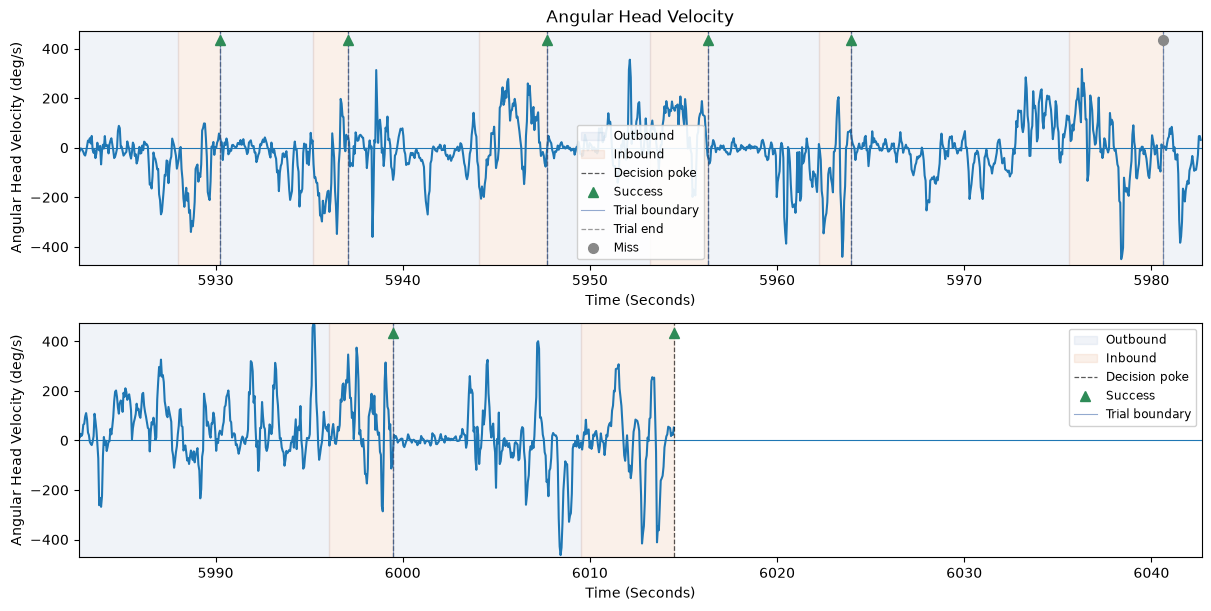

In [13]:
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)

ax = plot_ax_angular_head_velocity(ax = ax,
                                   angular_head_velocity=selected_angular_head_velocity,
                                   selected_trials=selected_trials,
                                   units = "deg/s",
                                   row_duration=60.0,
                                   subtitle="Angular Head Velocity",
                                   add_annotations_func=add_annotations,
                                   annotation_kwargs=None,
)

plt.show()
